In [2]:
import numpy as np
import pandas as pd

In [3]:
dt = pd.read_csv('datasets/CarPrice_Assignment.csv')
dt

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,2952,ohc,four,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.8,55.5,3049,ohc,four,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3012,ohcv,six,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3217,ohc,six,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


In [4]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [5]:
# Check for missing values if not any then go to duplicates
dt.isnull().any()

car_ID              False
symboling           False
CarName             False
fueltype            False
aspiration          False
doornumber          False
carbody             False
drivewheel          False
enginelocation      False
wheelbase           False
carlength           False
carwidth            False
carheight           False
curbweight          False
enginetype          False
cylindernumber      False
enginesize          False
fuelsystem          False
boreratio           False
stroke              False
compressionratio    False
horsepower          False
peakrpm             False
citympg             False
highwaympg          False
price               False
dtype: bool

In [6]:
dt.duplicated().any()
dt.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

EDA

In [7]:

import seaborn as sns
import matplotlib.pyplot as plt
import warnings

sns.set_style("whitegrid")

warnings.simplefilter(action='ignore', category=FutureWarning)

In [8]:
categorical_cols = dt.columns[dt.dtypes == 'object']
numberical_cols = dt.columns[dt.dtypes != 'object']

print(f"Categorical columns: {categorical_cols} and len: {len(categorical_cols)}")
print(f"Non-categorical columns: {numberical_cols} and len: {len(numberical_cols)}")



Categorical columns: Index(['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody',
       'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber',
       'fuelsystem'],
      dtype='object') and len: 10
Non-categorical columns: Index(['car_ID', 'symboling', 'wheelbase', 'carlength', 'carwidth',
       'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object') and len: 16


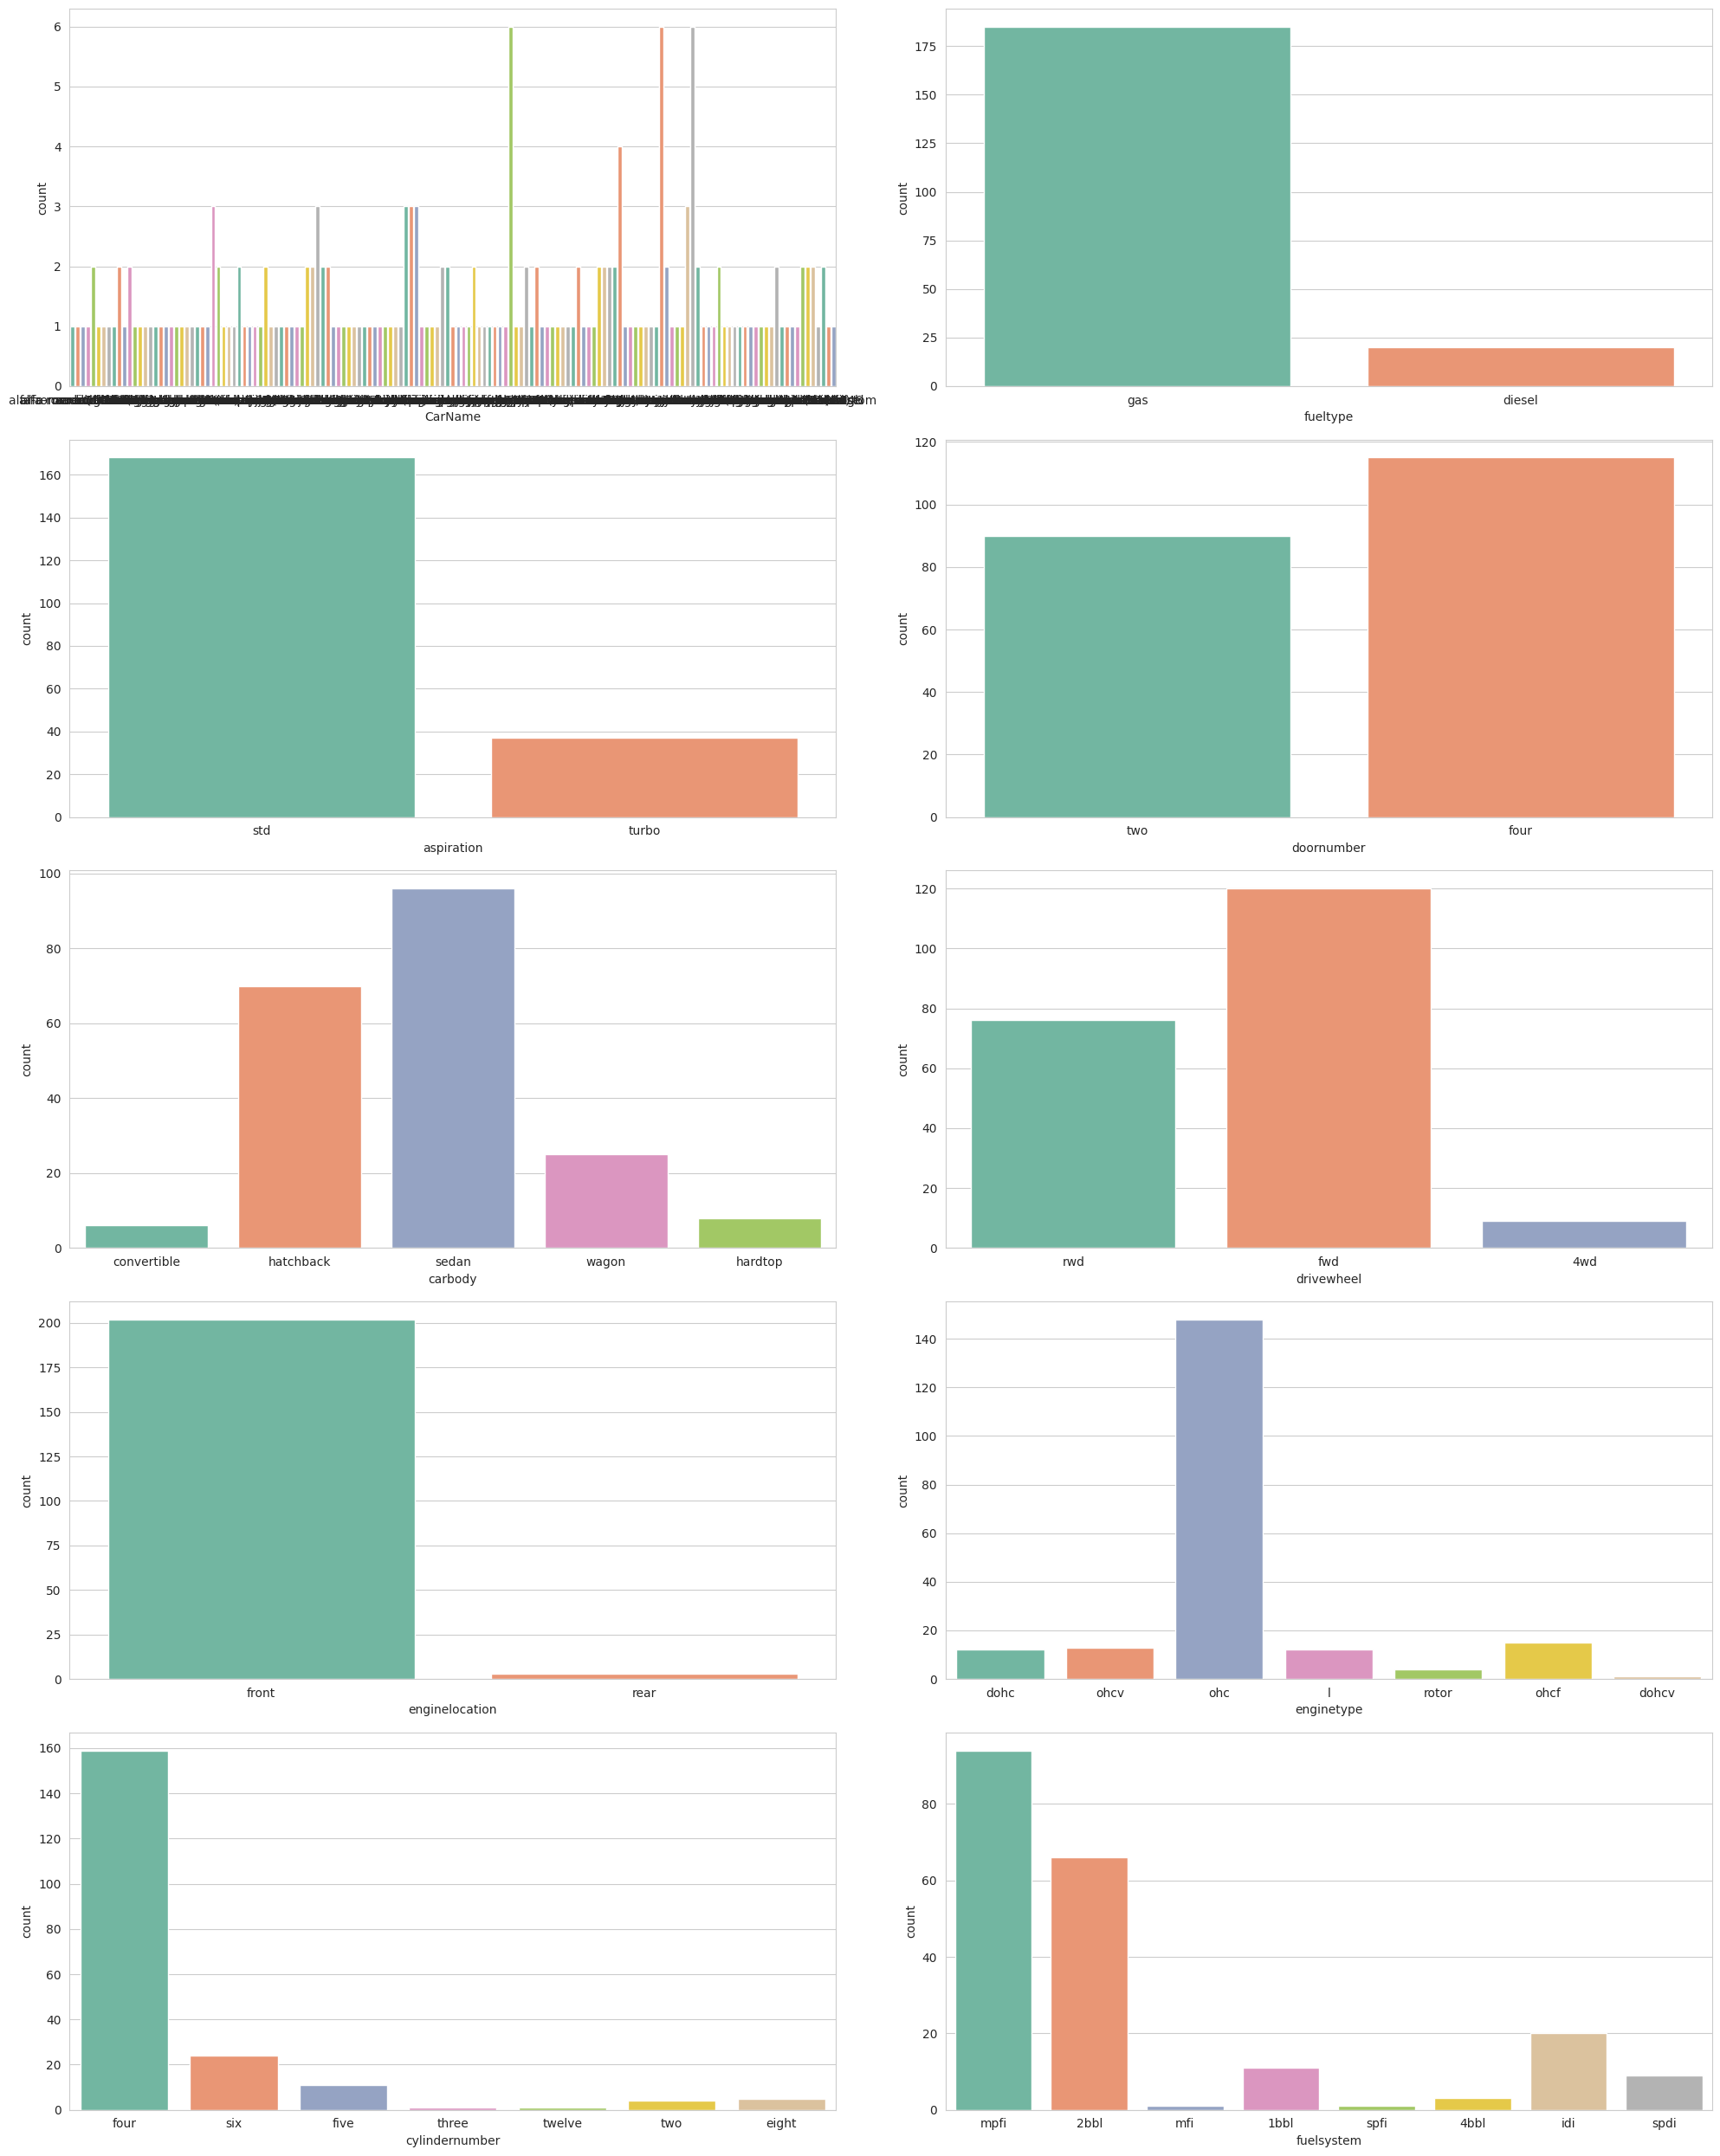

In [9]:
fig,ax=plt.subplots(5,2,figsize=(20,25))
ax=ax.flatten()
i=0
for col in categorical_cols:
    if(col == 'CarName'):
        sns.countplot(x=col, data=dt, ax=ax[i], palette='Set2' )
    sns.countplot(x=col, data=dt, ax=ax[i],palette='Set2')
    i += 1
plt.tight_layout()

plt.show()


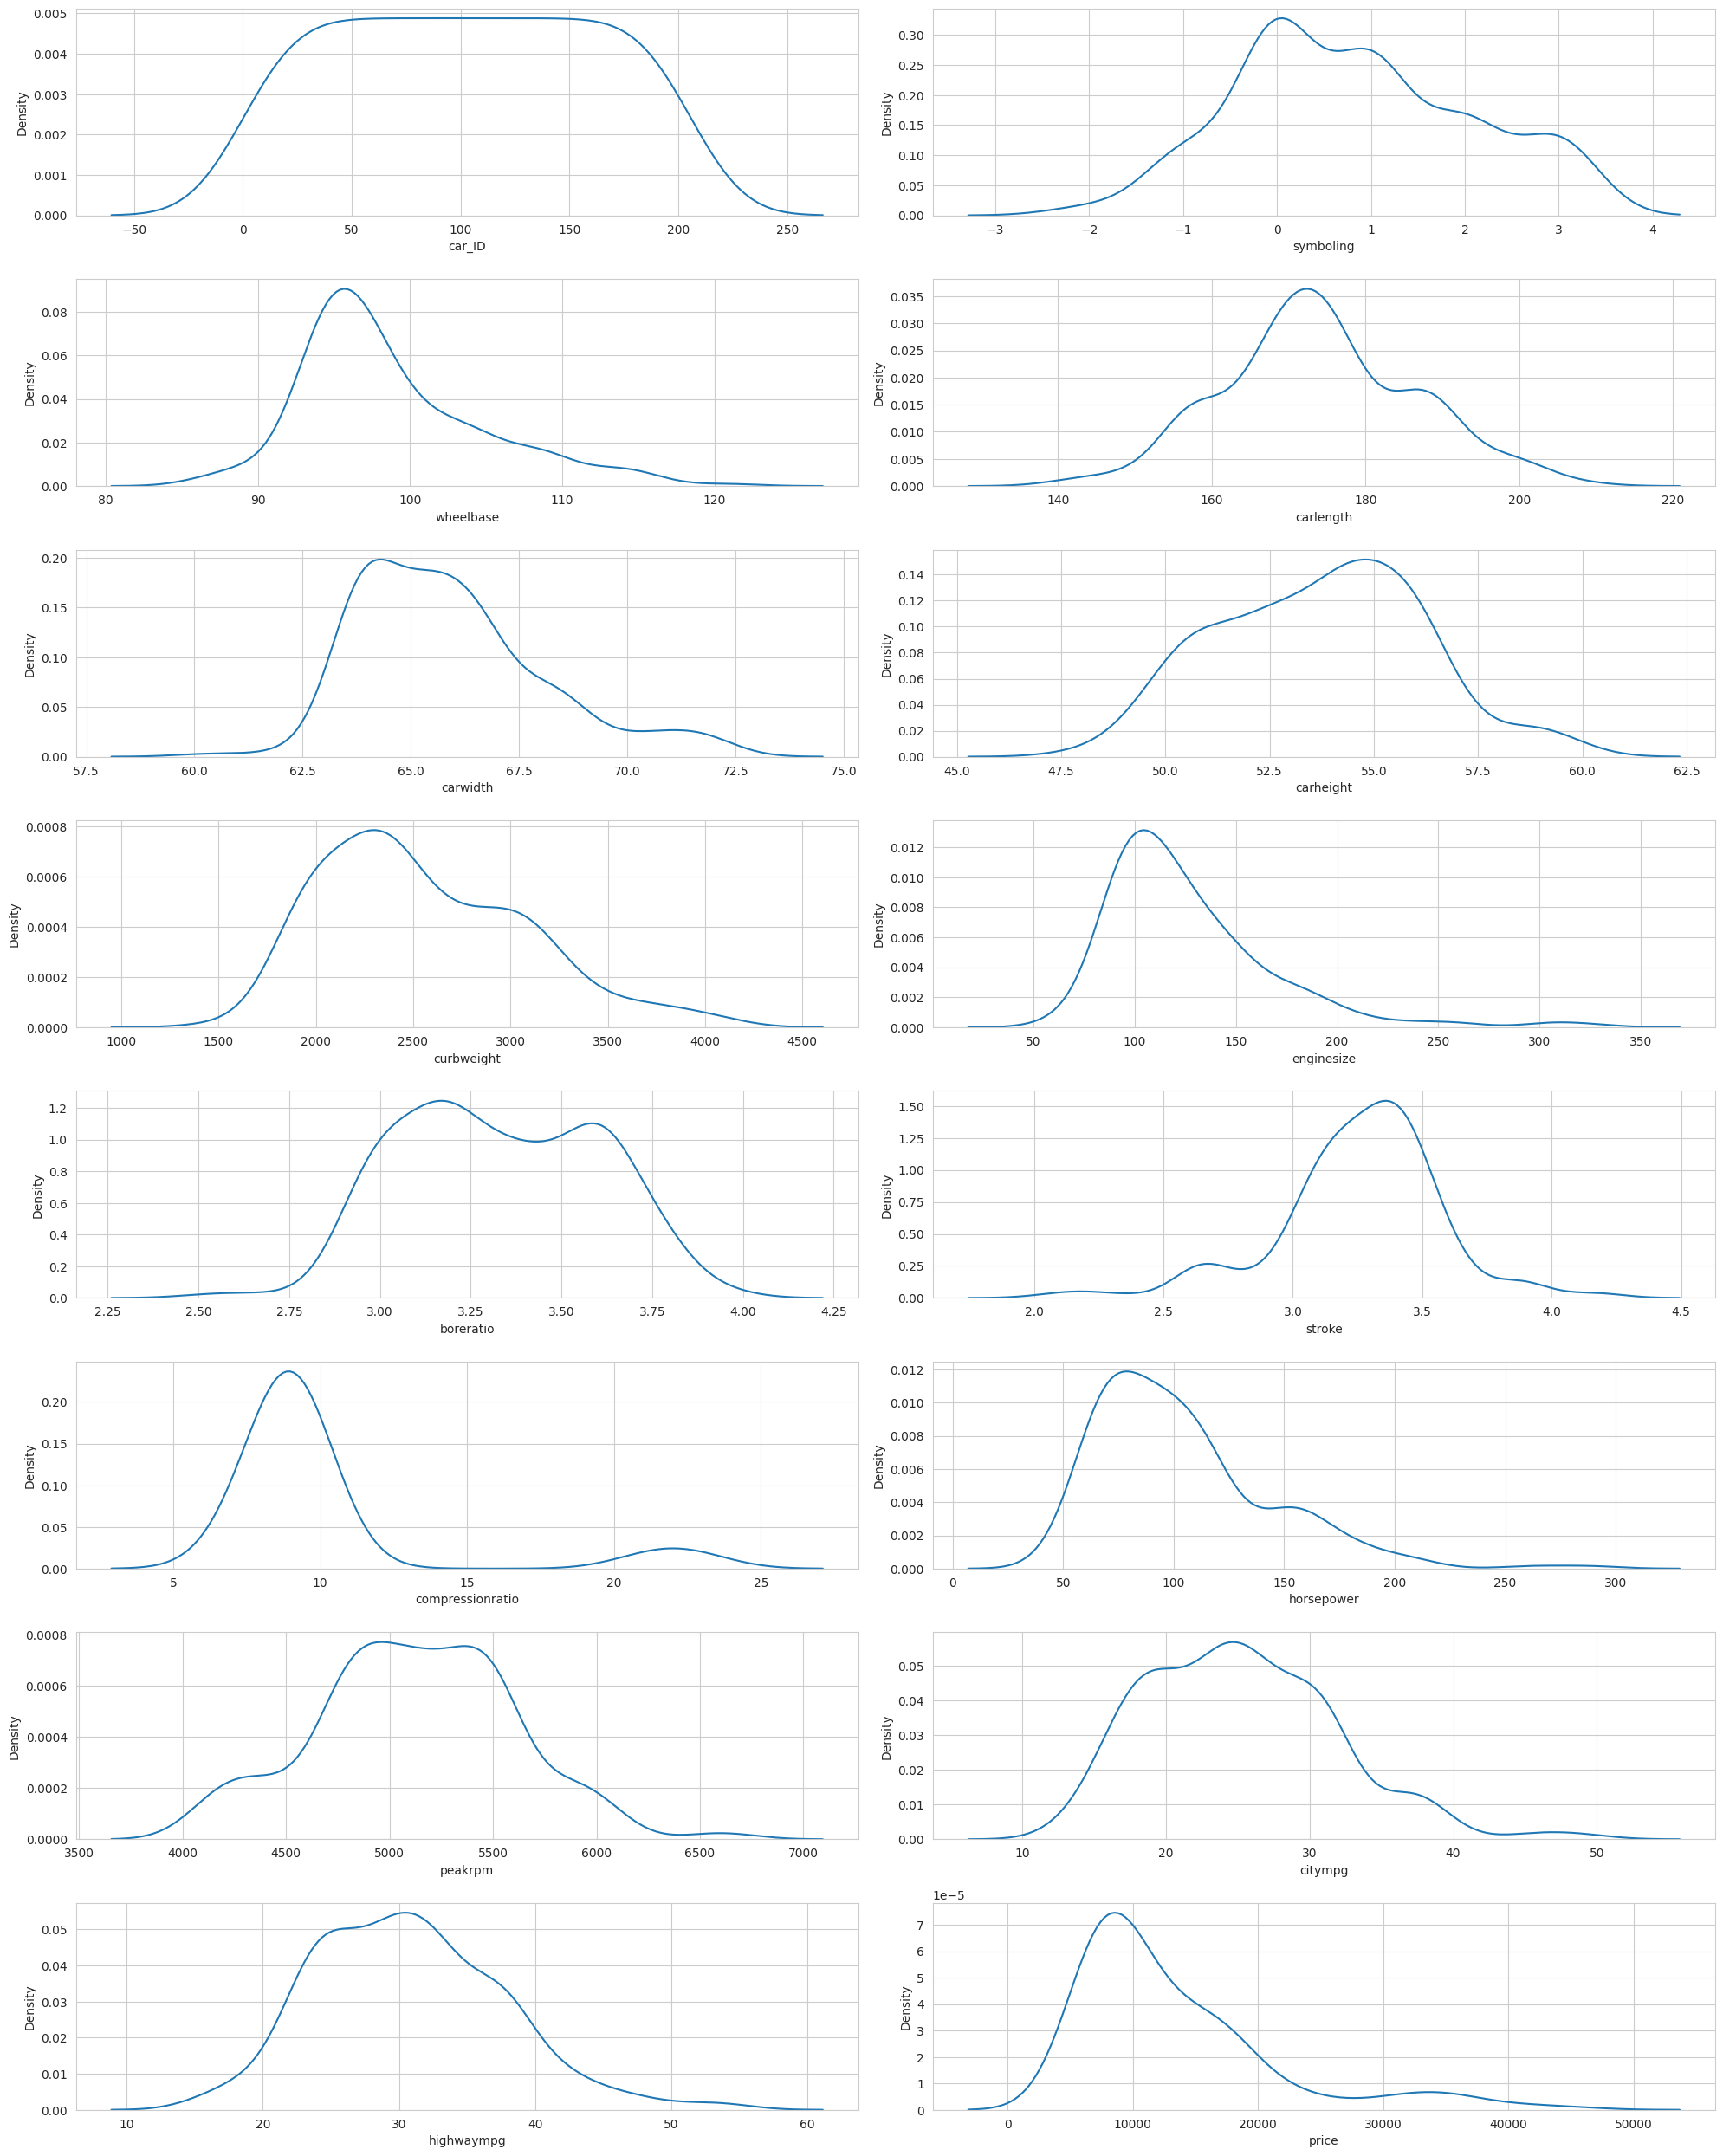

In [10]:
fig,ax = plt.subplots(8,2,figsize=(20,25))
ax=ax.flatten()
i=0
for col in numberical_cols:
    sns.kdeplot(x=col, data=dt, ax=ax[i])
    i += 1
plt.tight_layout()
plt.show()


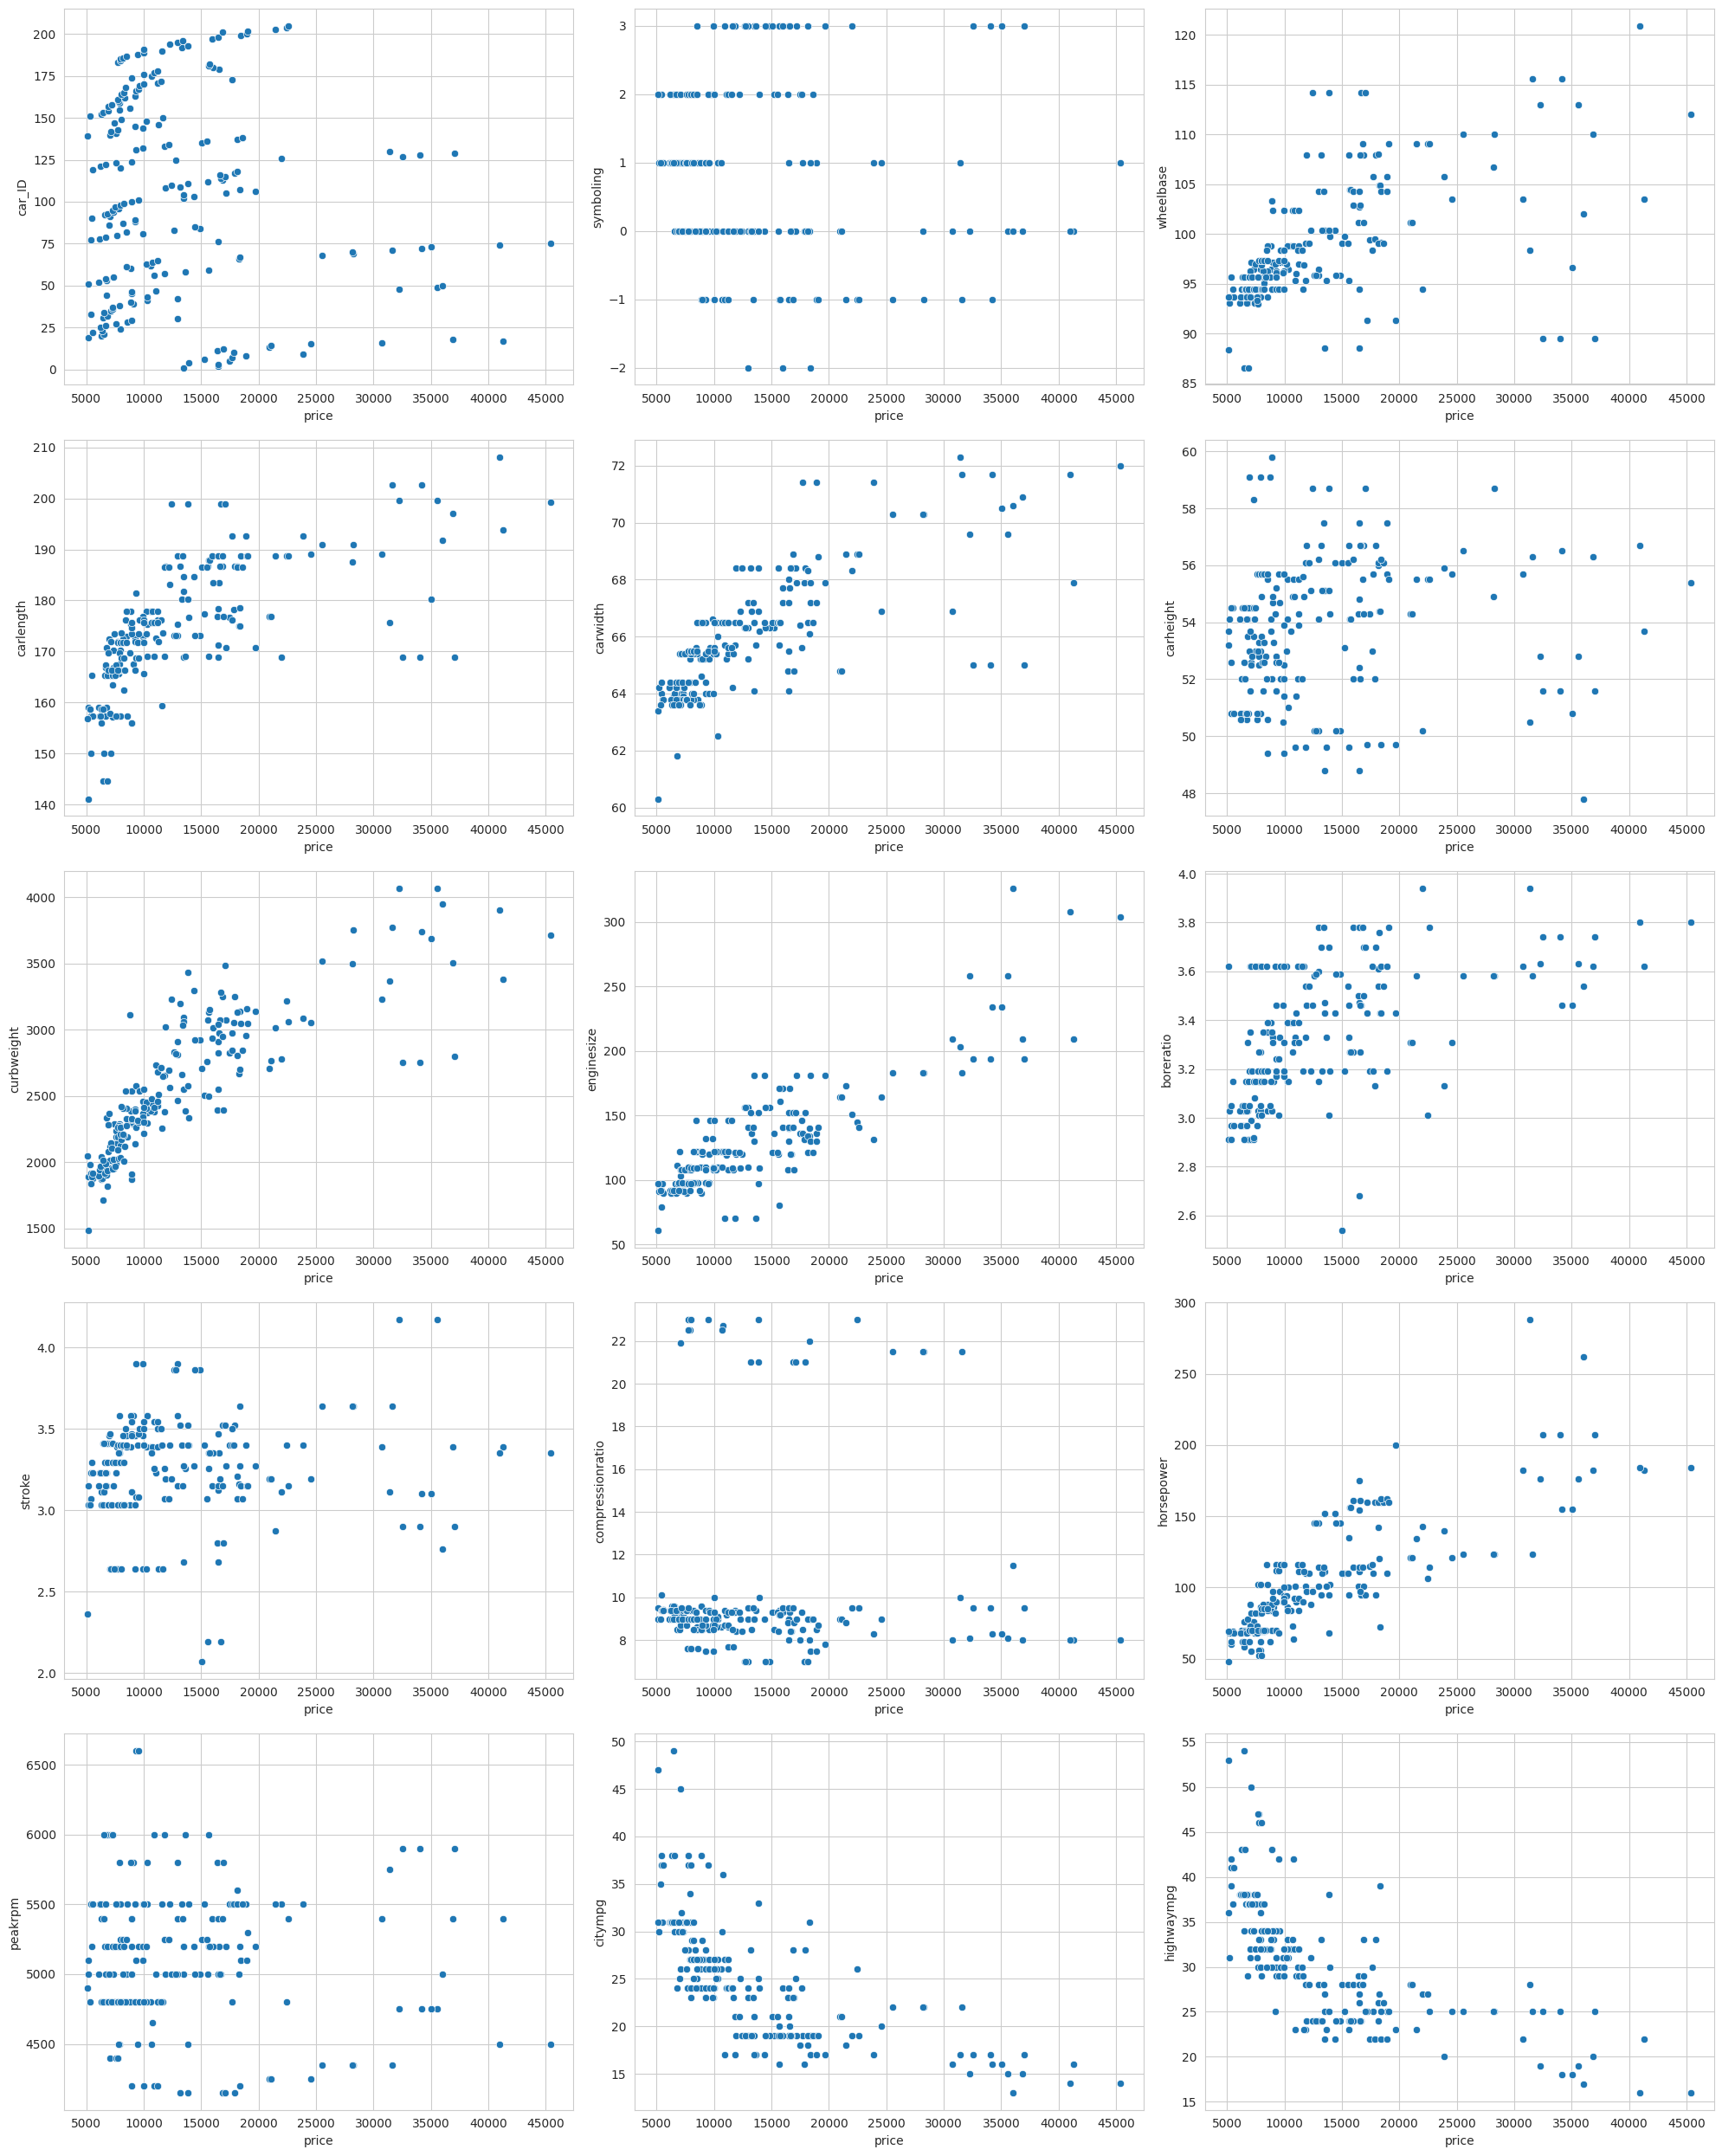

In [11]:
#numurical column relation to the target variable (price)
fig, ax = plt.subplots(5, 3, figsize=(20, 25))
ax = ax.flatten()
i = 0
for col in numberical_cols:
    if col == 'price':
        continue
    sns.scatterplot(x='price', y=col, data=dt, ax=ax[i])
    i += 1
plt.tight_layout()
plt.show()

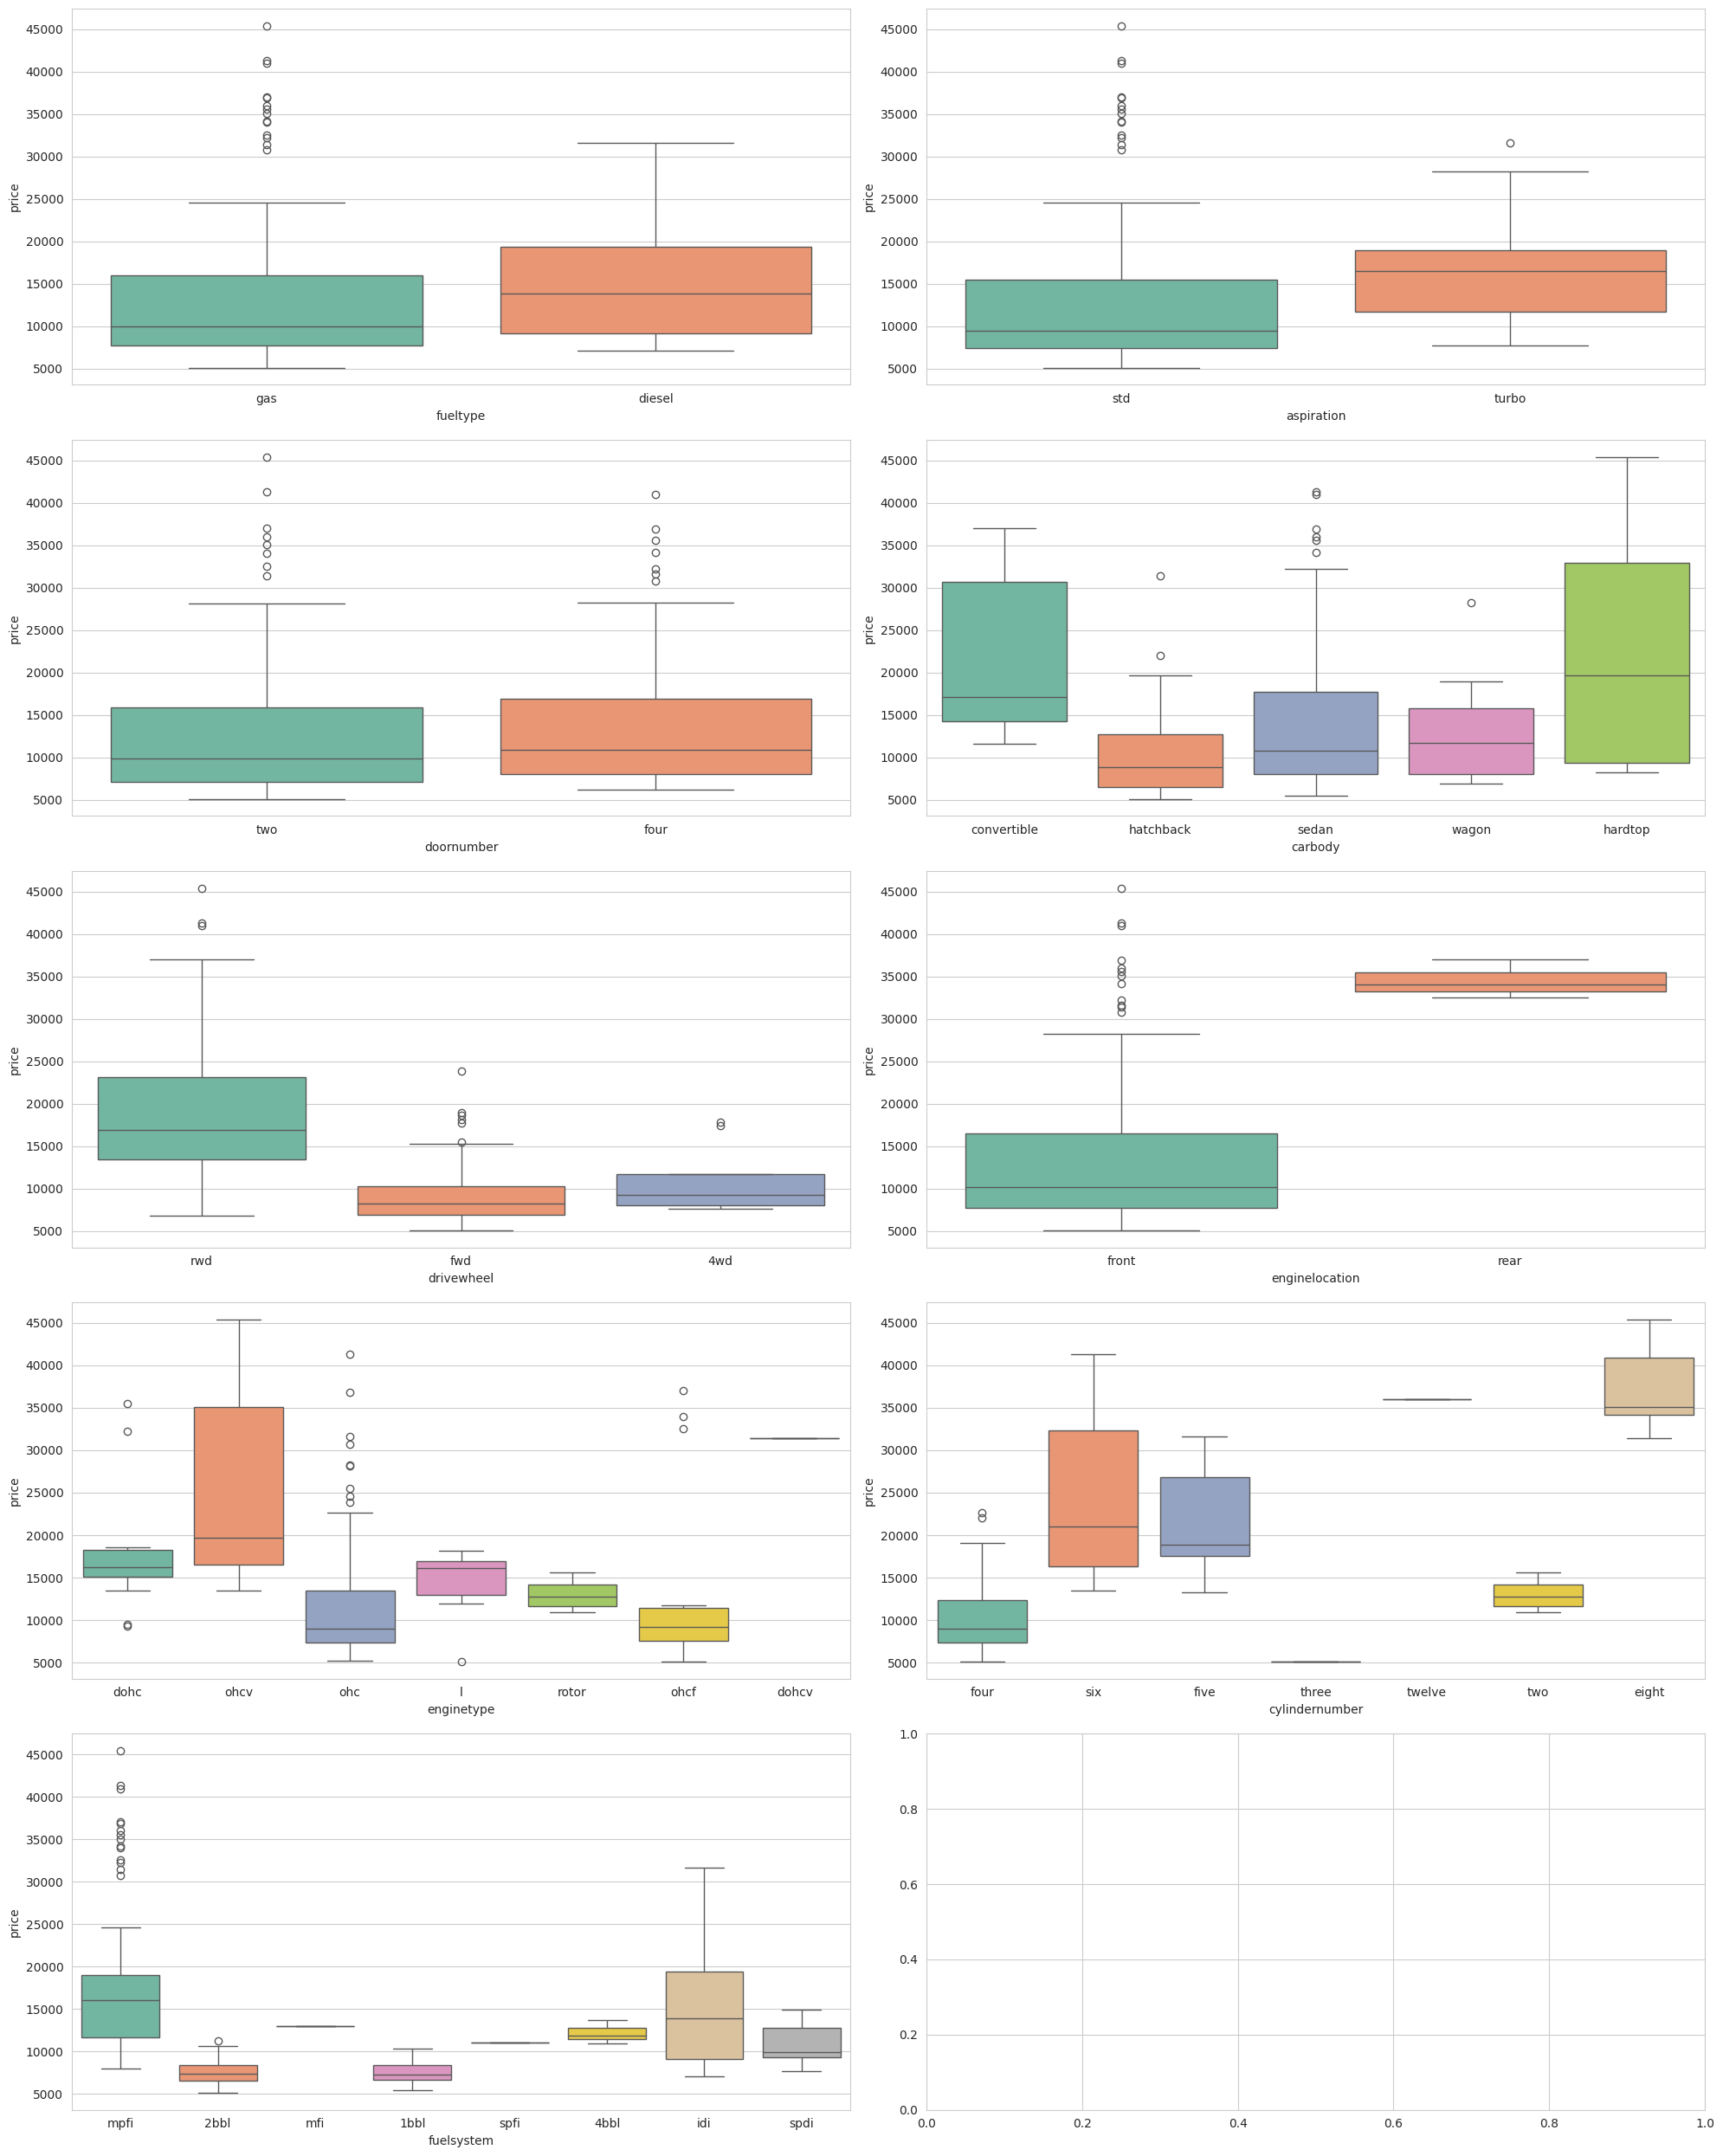

In [12]:
#categorical column relation to the target variable (price)

fig, ax = plt.subplots(5, 2, figsize=(20, 25))
ax = ax.flatten()
i = 0
for col in categorical_cols:
    if col == 'CarName':
        continue
    sns.boxplot(y='price', x=col, data=dt, ax=ax[i],palette='Set2')
    i += 1
plt.tight_layout()
plt.show()


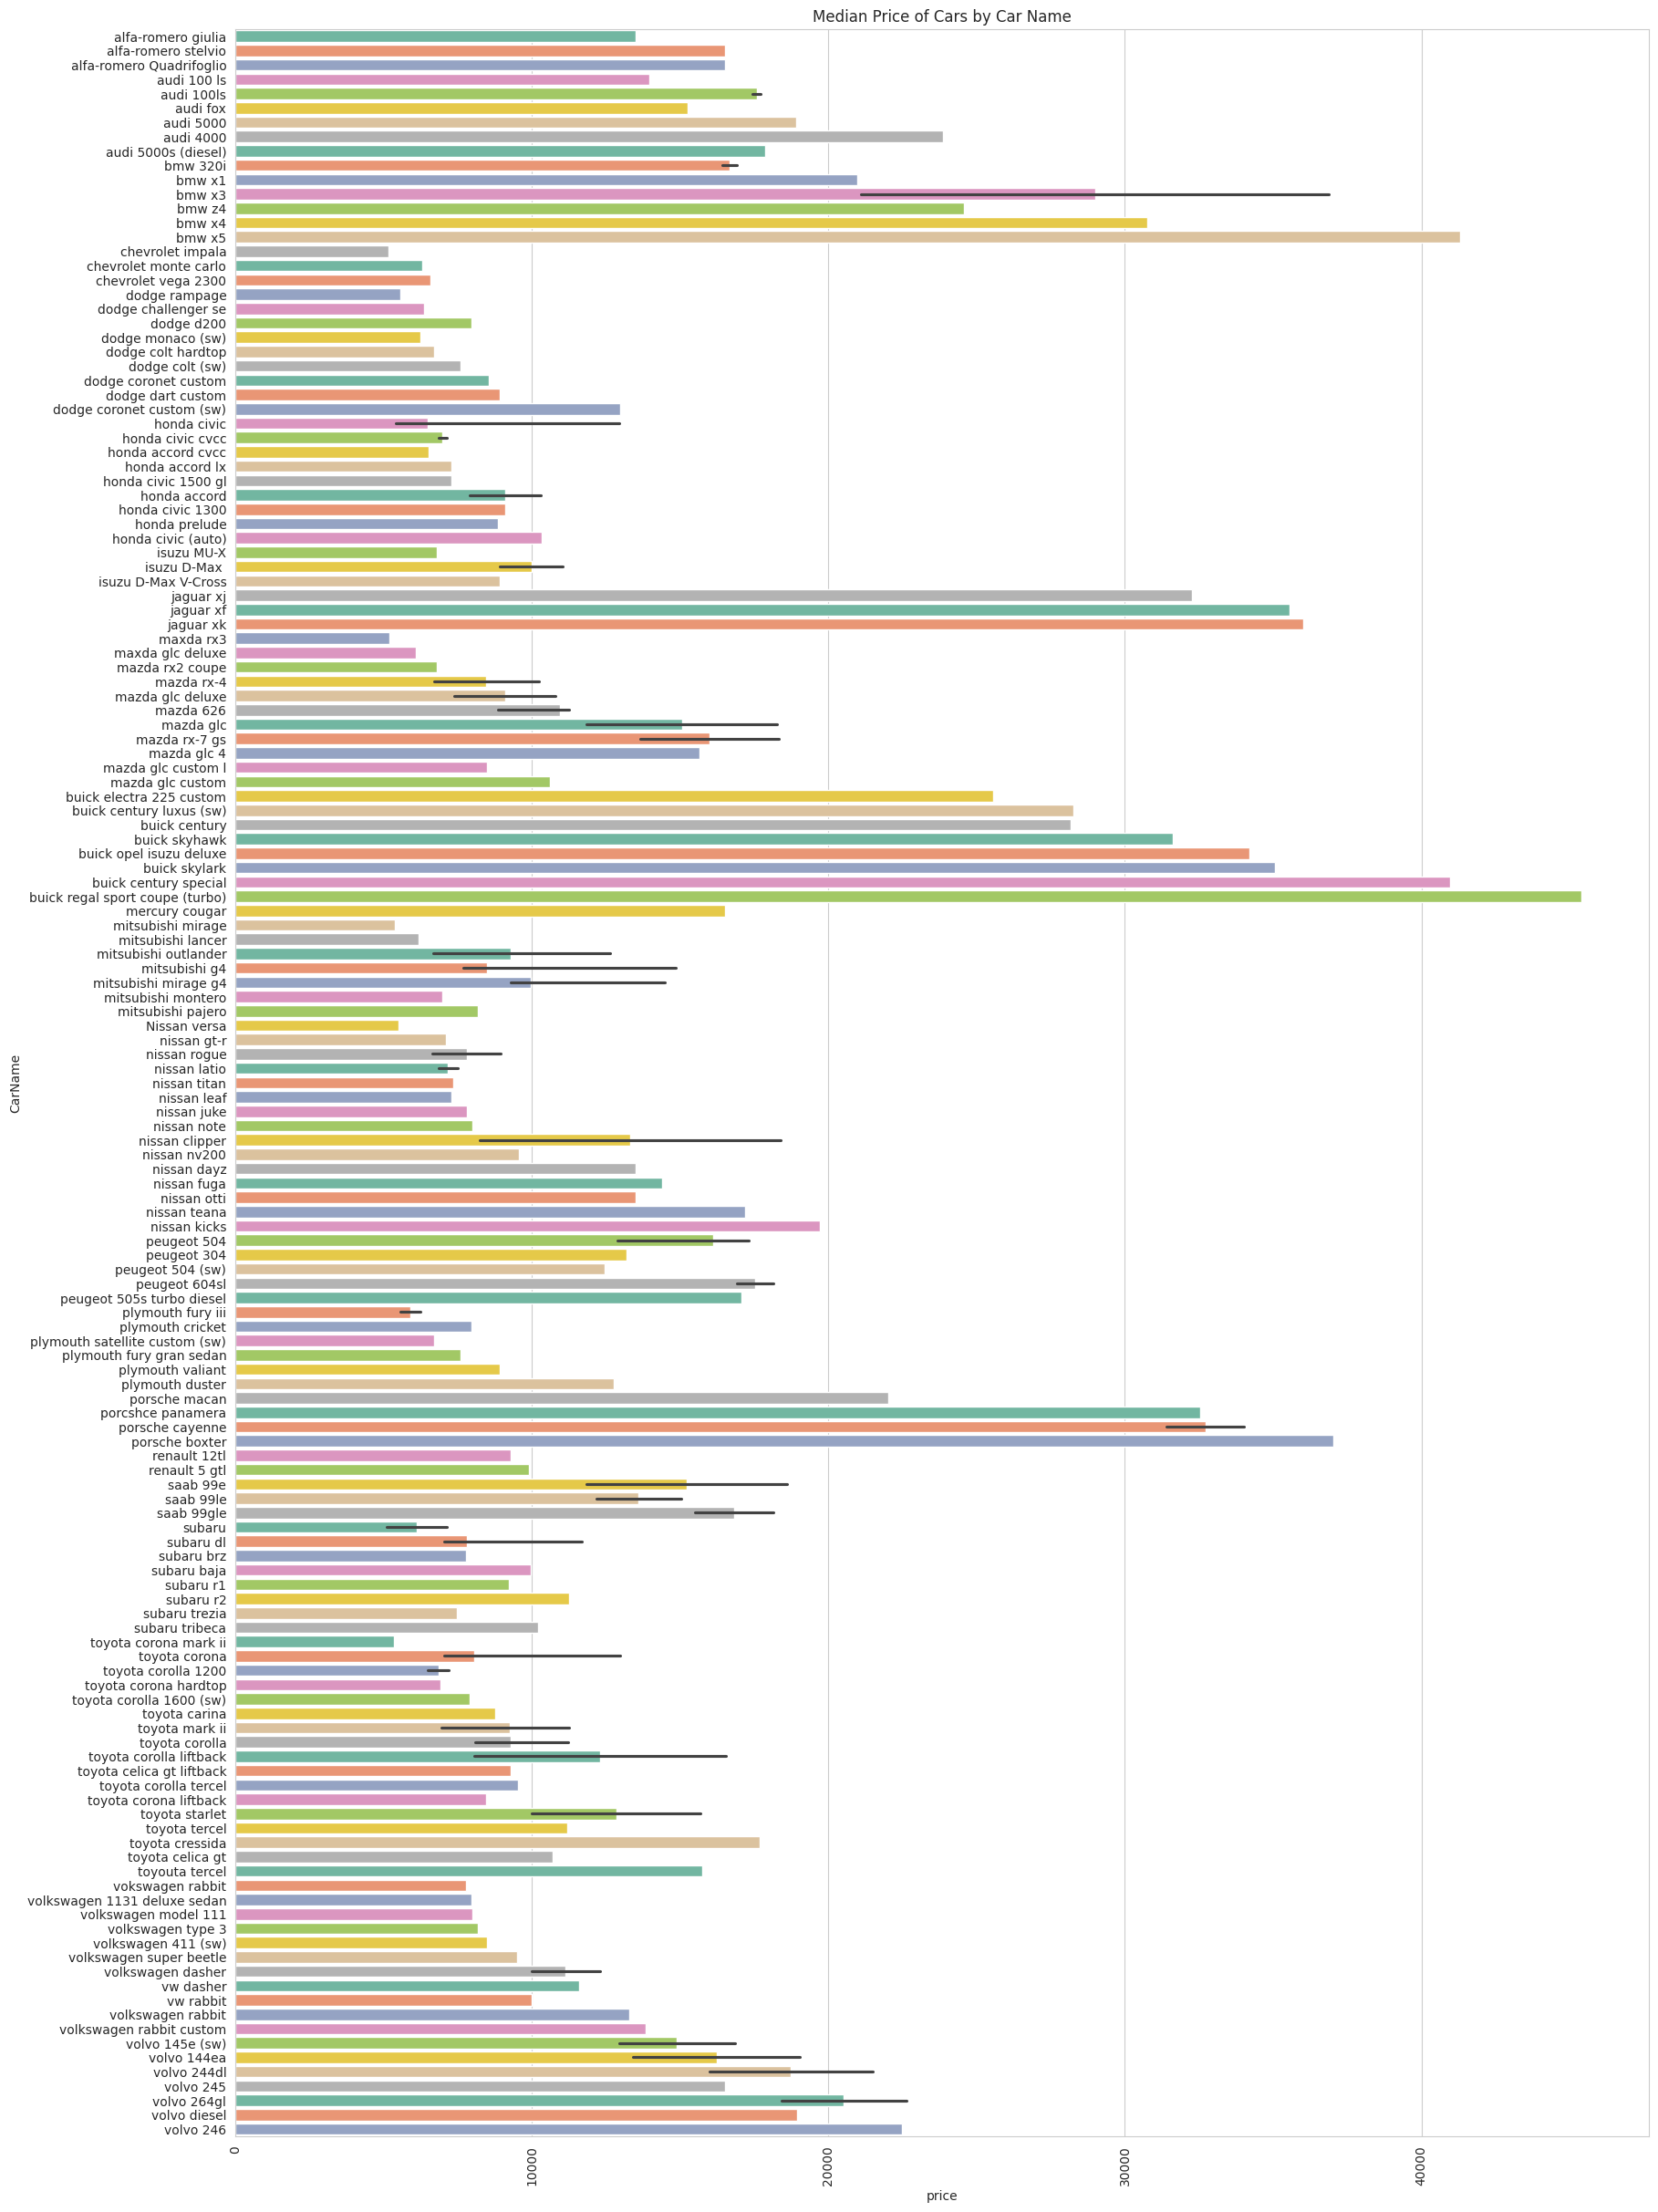

In [13]:
plt.figure(figsize=(20,30))

sns.barplot(y='CarName',x='price',data=dt,estimator=np.median,palette='Set2')
plt.xticks(rotation=90)
plt.title('Median Price of Cars by Car Name')
plt.show()

In [14]:
#let take in the categorical column and convert it to numerical using label encoding
categorical_cols = dt.columns[dt.dtypes == 'object']
target_label = 'price'
for col in categorical_cols:
    print(f"Original column: {col}")
    target_mean = dt.groupby(col)[target_label].mean()
    print(f"Target mean for {col}:\n{target_mean}\n")
    dt[col+'_enc'] = dt[col].map(target_mean)
    print(f"Encoded column: {col+'_enc'}\n")
    print(f"Encoded column values:\n{dt[col+'_enc'].unique()}\n")
    dt.drop(col, axis=1, inplace=True)
    

Original column: CarName
Target mean for CarName:
CarName
Nissan versa                 5499.0
alfa-romero Quadrifoglio    16500.0
alfa-romero giulia          13495.0
alfa-romero stelvio         16500.0
audi 100 ls                 13950.0
                             ...   
volvo 246                   22470.0
volvo 264gl                 20522.5
volvo diesel                18950.0
vw dasher                   11595.0
vw rabbit                    9980.0
Name: price, Length: 147, dtype: float64

Encoded column: CarName_enc

Encoded column values:
[13495.         16500.         13950.         17580.
 15250.         18920.         23875.         17859.167
 16677.5        20970.         28992.5        24565.
 30760.         41315.          5151.          6295.
  6575.          5572.          6377.          7957.
  6229.          6692.          7609.          8558.
  8921.         12964.          8274.33333333  6992.
  6529.          7295.          9095.          8845.
 10345.          6785.   

In [15]:
dt.info()

##  it's all set  numerical columns and no missing values for model training


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   car_ID              205 non-null    int64  
 1   symboling           205 non-null    int64  
 2   wheelbase           205 non-null    float64
 3   carlength           205 non-null    float64
 4   carwidth            205 non-null    float64
 5   carheight           205 non-null    float64
 6   curbweight          205 non-null    int64  
 7   enginesize          205 non-null    int64  
 8   boreratio           205 non-null    float64
 9   stroke              205 non-null    float64
 10  compressionratio    205 non-null    float64
 11  horsepower          205 non-null    int64  
 12  peakrpm             205 non-null    int64  
 13  citympg             205 non-null    int64  
 14  highwaympg          205 non-null    int64  
 15  price               205 non-null    float64
 16  CarName_

Feature Engineering

In [16]:
from sklearn.feature_selection import mutual_info_regression



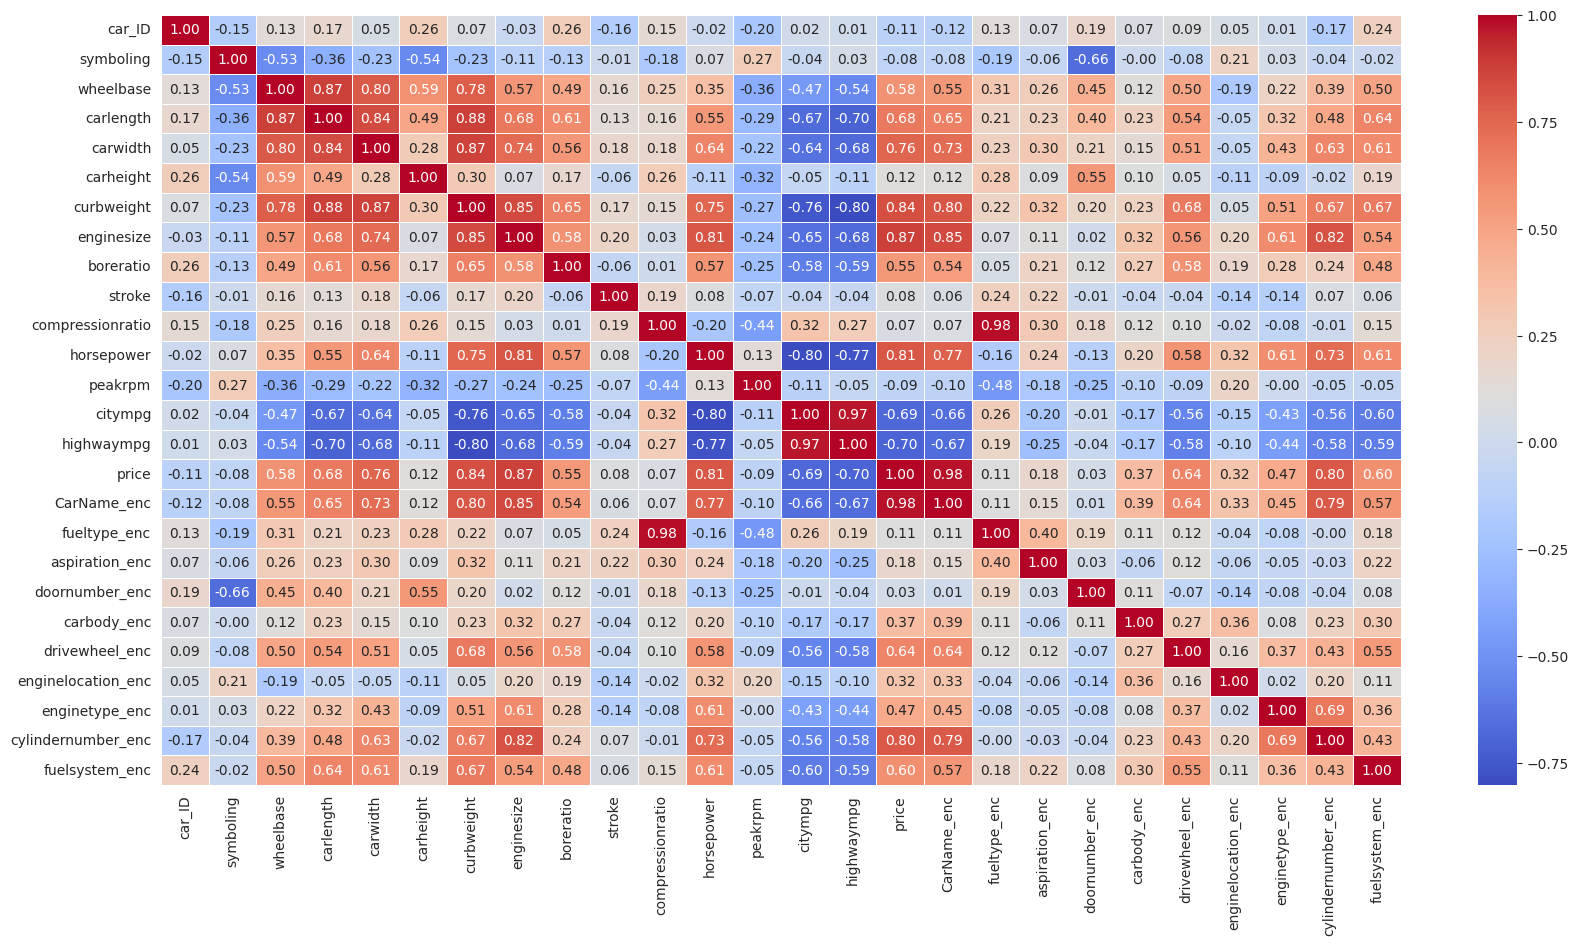

In [17]:
plt.figure(figsize=(20, 10))
sns.heatmap(dt.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.show()

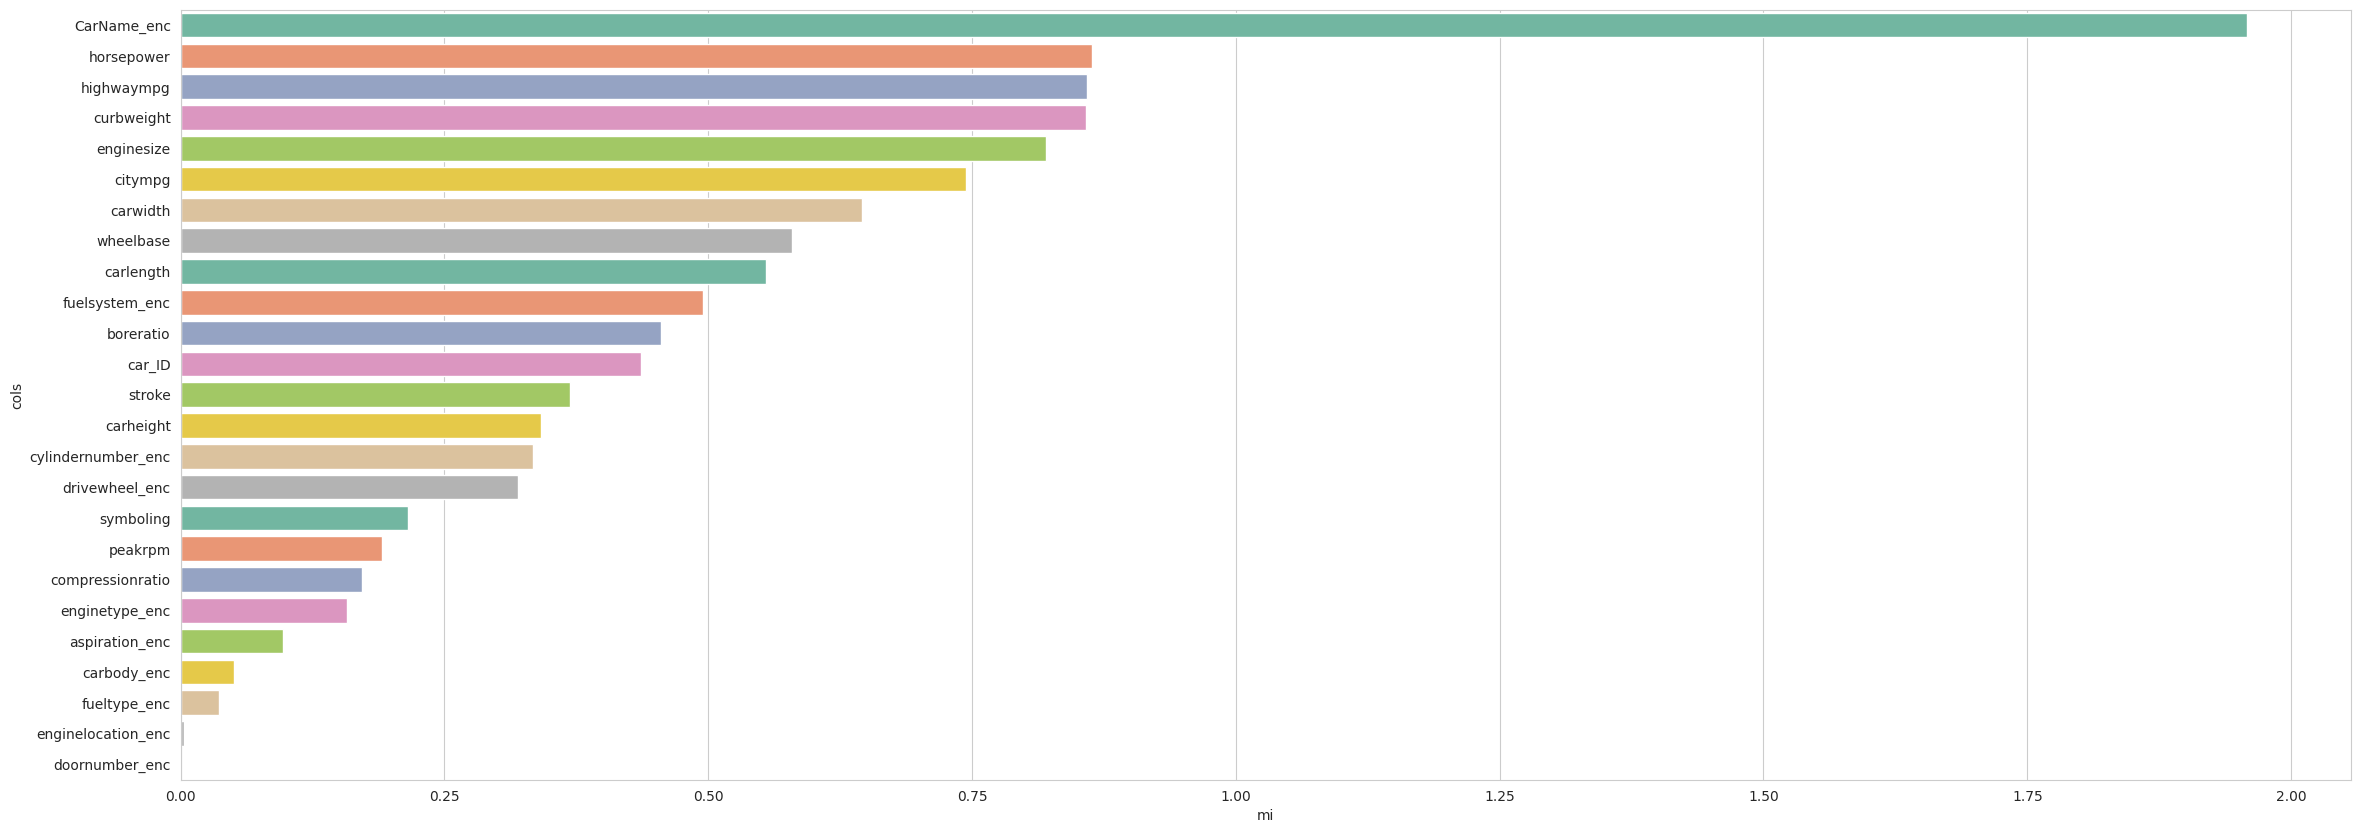

In [18]:
x=dt.drop(columns=['price'])
y=dt['price']

mutual_info=mutual_info_regression(x,y)
mutual_info_df=pd.DataFrame({'cols':x.columns,'mi':mutual_info})
mutual_info_df.sort_values(by='mi', ascending=False, inplace=True)

plt.figure(figsize=(28,10))
sns.barplot(x='mi', y='cols', data=mutual_info_df, palette='Set2')
plt.show()

Make data set to train set and test set

In [19]:
from sklearn.model_selection import train_test_split
x = dt.drop(columns=['price'])
y = dt['price']

print(f"price before transformation:\n{y.describe()}\n")

y = np.log1p(y)  # Apply log transformation to the target variable
print(f"price after transformation:\n{y.describe()}\n")

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


price before transformation:
count      205.000000
mean     13276.710571
std       7988.852332
min       5118.000000
25%       7788.000000
50%      10295.000000
75%      16503.000000
max      45400.000000
Name: price, dtype: float64

price after transformation:
count    205.000000
mean       9.354776
std        0.503765
min        8.540714
25%        8.960468
50%        9.239511
75%        9.711358
max       10.723289
Name: price, dtype: float64



In [20]:
#see throgh the data shape look like
print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


x_train shape: (164, 25)
x_test shape: (41, 25)
y_train shape: (164,)
y_test shape: (41,)


In [23]:
#So after all the EDA and feature engineering we have a dataset ready for model training

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import  RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

rf_xtrain = x_train.copy()
rf_xtest = x_test.copy()
rf_ytrain = y_train.copy()
rf_ytest = y_test.copy()
rf=RandomForestRegressor(random_state=42)
fine_tuned_params = {
    'n_estimators': [1000],
    'max_features': ['auto', 'sqrt'],
    'max_depth':list(np.arange(1,51)),
    'min_samples_split': list(np.arange(2, 51)),
    'min_samples_leaf': list(np.arange(1, 51)),
    
}

rf_search= RandomizedSearchCV(estimator=rf, param_distributions=fine_tuned_params, n_iter=100, cv=5, verbose=2, random_state=42, n_jobs=-1)
rf_search.fit(rf_xtrain, rf_ytrain)
print(f"Best parameters: {rf_search.best_params_}")
print(f"Best score: {rf_search.best_score_}")
rf_search= rf_search.best_estimator_


Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=48, min_samples_split=16, n_estimators=1000; total time=   1.7s
[CV] END max_depth=25, max_features=sqrt, min_samples_leaf=39, min_samples_split=48, n_estimators=1000; total time=   1.7s
[CV] END max_depth=25, max_features=sqrt, min_samples_leaf=39, min_samples_split=48, n_estimators=1000; total time=   1.8s
[CV] END max_depth=25, max_features=sqrt, min_samples_leaf=39, min_samples_split=48, n_estimators=1000; total time=   1.8s
[CV] END max_depth=22, max_features=auto, min_samples_leaf=17, min_samples_split=12, n_estimators=1000; total time=   0.0s
[CV] END max_depth=22, max_features=auto, min_samples_leaf=17, min_samples_split=12, n_estimators=1000; total time=   0.0s
[CV] END max_depth=22, max_features=auto, min_samples_leaf=17, min_samples_split=12, n_estimators=1000; total time=   0.0s
[CV] END max_depth=25, max_features=sqrt, min_samples_leaf=39, min_samples_s

/home/june/Documents/GitHub/car-price-prediction/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
240 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
123 fits failed with the following error:
Traceback (most recent call last):
  File "/home/june/Documents/GitHub/car-price-prediction/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/june/Documents/GitHub/car-price-prediction/.venv/lib/python3.13/site-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~

Best parameters: {'n_estimators': 1000, 'min_samples_split': np.int64(6), 'min_samples_leaf': np.int64(2), 'max_features': 'sqrt', 'max_depth': np.int64(31)}
Best score: 0.9354546016167186


In [ ]:
pred_train = rf_search.predict(rf_xtrain)
pred_test = rf_search.predict(rf_xtest)
print(f"Train RMSE: {np.sqrt(mean_squared_error(rf_ytrain, pred_train))}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(rf_ytest, pred_test))}")
print(f"Train R2: {r2_score(rf_ytrain, pred_train)}")
print(f"Test R2: {r2_score(rf_ytest, pred_test)}")

Train RMSE: 0.07149603101531198
Test RMSE: 0.11662842169022974
Train R2: 0.9793762395630922
Test R2: 0.9498600996230426
